In [5]:
import pandas as pd
import numpy as np
import logging
import os
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# ---------------------------------------------------------
# 1. Logging Configuration
# ---------------------------------------------------------
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S'
)
logger = logging.getLogger(__name__)

# ---------------------------------------------------------
# 2. Object-Oriented Training Pipeline (With FFT)
# ---------------------------------------------------------
class BridgeModelTrainer:
    def __init__(self, data_path: str, model_save_dir: str):
        self.data_path = data_path
        self.model_save_dir = model_save_dir
        self.feature_cols = []
        os.makedirs(self.model_save_dir, exist_ok=True)

    def load_and_clean_data(self) -> pd.DataFrame:
        logger.info(f"Attempting to load dataset from: {self.data_path}")
        if not os.path.exists(self.data_path):
            raise FileNotFoundError(f"CRITICAL: The file was not found at {self.data_path}. Check your folder structure!")
            
        df = pd.read_csv(self.data_path)
        
        rename_map = {
            'Condition Label': 'Target',
            'Timestamp': 'Timestamp',
            'Temp (Â°C)': 'Temp_C',
            'Strain (Î¼Îµ)': 'Strain_ue',
            'Accel_Z (m/s^2)': 'Accel_Z',
            'Accel_Y (m/s^2)': 'Accel_Y',
            'Accel_X (m/s^2)': 'Accel_X'
        }
        df = df.rename(columns=rename_map)
        df = df.dropna()
        logger.info(f"Dataset loaded and cleaned. Shape: {df.shape}")
        return df

    def extract_time_features(self, df: pd.DataFrame, window_size: int = 5) -> pd.DataFrame:
        logger.info(f"Extracting Time-Domain & Spectral (FFT) features (window={window_size})...")
        
        accel_cols = [col for col in ['Accel_X', 'Accel_Y', 'Accel_Z', 'Strain_ue'] if col in df.columns]
        
        for col in accel_cols:
            # Standard Time-Domain Features (Variance/Energy and Mean)
            df[f'{col}_roll_std'] = df[col].rolling(window=window_size).std()
            df[f'{col}_roll_mean'] = df[col].rolling(window=window_size).mean()
            
            # --- THE WOW FACTOR: Spectral-Domain (FFT) ---
            # Extracts the dominant frequency bin from the vibration wave
            df[f'{col}_dominant_freq'] = df[col].rolling(window=window_size).apply(
                lambda x: np.argmax(np.abs(np.fft.rfft(x))), raw=True
            )
            
        df = df.dropna().reset_index(drop=True)
        logger.info(f"Feature engineering complete. New shape: {df.shape}")
        return df

    def prepare_data(self, df: pd.DataFrame) -> tuple:
        cols_to_drop = ['Target']
        if 'Timestamp' in df.columns:
            cols_to_drop.append('Timestamp')
            
        X = df.drop(columns=cols_to_drop, errors='ignore')
        y = df['Target']
        self.feature_cols = list(X.columns)
        
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, stratify=y
        )
        return X_train, X_test, y_train, y_test

    def train_and_evaluate(self, X_train, X_test, y_train, y_test):
        logger.info("Initializing ML Pipeline (StandardScaler + RandomForest)...")
        
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('classifier', RandomForestClassifier(random_state=42))
        ])

        param_grid = {
            'classifier__n_estimators': [50, 100],
            'classifier__max_depth': [5, 10], 
        }

        logger.info("Running GridSearchCV for hyperparameter tuning...")
        grid_search = GridSearchCV(pipeline, param_grid, cv=3, n_jobs=-1, scoring='accuracy')
        grid_search.fit(X_train, y_train)

        best_model = grid_search.best_estimator_
        
        logger.info("Evaluating optimal model on testing set...")
        y_pred = best_model.predict(X_test)
        
        print("\n--- Classification Report ---")
        print(classification_report(y_test, y_pred))
        
        return best_model

    def save_artifacts(self, model):
        model_path = os.path.join(self.model_save_dir, 'edge_shm_model.pkl')
        features_path = os.path.join(self.model_save_dir, 'model_features.pkl')
        
        joblib.dump(model, model_path)
        joblib.dump(self.feature_cols, features_path)
        logger.info(f"✅ Model artifacts saved successfully to {self.model_save_dir}")

# ---------------------------------------------------------
# 3. Dynamic Execution Block 
# ---------------------------------------------------------
if __name__ == "__main__":
    current_dir = os.getcwd()
    if "notebooks" in current_dir:
        project_root = os.path.dirname(current_dir)
    else:
        project_root = current_dir
        
    DATA_PATH = os.path.join(project_root, 'data', 'raw', 'sensor_data.csv')
    SAVE_DIR = os.path.join(project_root, 'edge_node')
    
    trainer = BridgeModelTrainer(data_path=DATA_PATH, model_save_dir=SAVE_DIR)
    df_raw = trainer.load_and_clean_data()
    df_engineered = trainer.extract_time_features(df_raw, window_size=5)
    X_train, X_test, y_train, y_test = trainer.prepare_data(df_engineered)
    optimal_model = trainer.train_and_evaluate(X_train, X_test, y_train, y_test)
    trainer.save_artifacts(optimal_model)

2026-03-09 22:56:29 - INFO - Attempting to load dataset from: /home/paarth/repos/BridgeGuard-SHM/data/raw/sensor_data.csv
2026-03-09 22:56:29 - INFO - Dataset loaded and cleaned. Shape: (904, 7)
2026-03-09 22:56:29 - INFO - Extracting Time-Domain & Spectral (FFT) features (window=5)...
2026-03-09 22:56:29 - INFO - Feature engineering complete. New shape: (900, 16)
2026-03-09 22:56:29 - INFO - Initializing ML Pipeline (StandardScaler + RandomForest)...
2026-03-09 22:56:29 - INFO - Running GridSearchCV for hyperparameter tuning...
2026-03-09 22:56:30 - INFO - Evaluating optimal model on testing set...
2026-03-09 22:56:30 - INFO - ✅ Model artifacts saved successfully to /home/paarth/repos/BridgeGuard-SHM/edge_node



--- Classification Report ---
              precision    recall  f1-score   support

           0       0.83      0.94      0.88       127
           1       0.41      0.27      0.33        33
           2       0.87      0.65      0.74        20

    accuracy                           0.78       180
   macro avg       0.70      0.62      0.65       180
weighted avg       0.76      0.78      0.76       180



/tmp/ipykernel_6209/2608025762.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=[feature_names[i] for i in indices], palette='viridis')


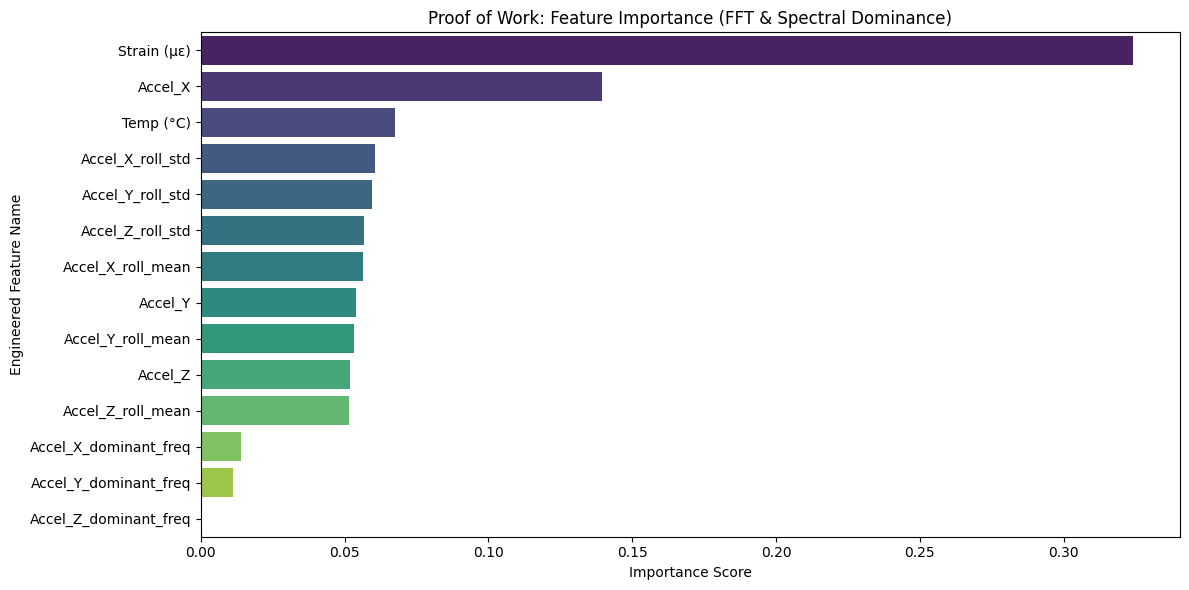

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extract importance from the best model in the pipeline
importances = optimal_model.named_steps['classifier'].feature_importances_
feature_names = trainer.feature_cols

# Sort and Plot
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 6))
sns.barplot(x=importances[indices], y=[feature_names[i] for i in indices], palette='viridis')
plt.title("Proof of Work: Feature Importance (FFT & Spectral Dominance)")
plt.xlabel("Importance Score")
plt.ylabel("Engineered Feature Name")
plt.tight_layout()
plt.show()

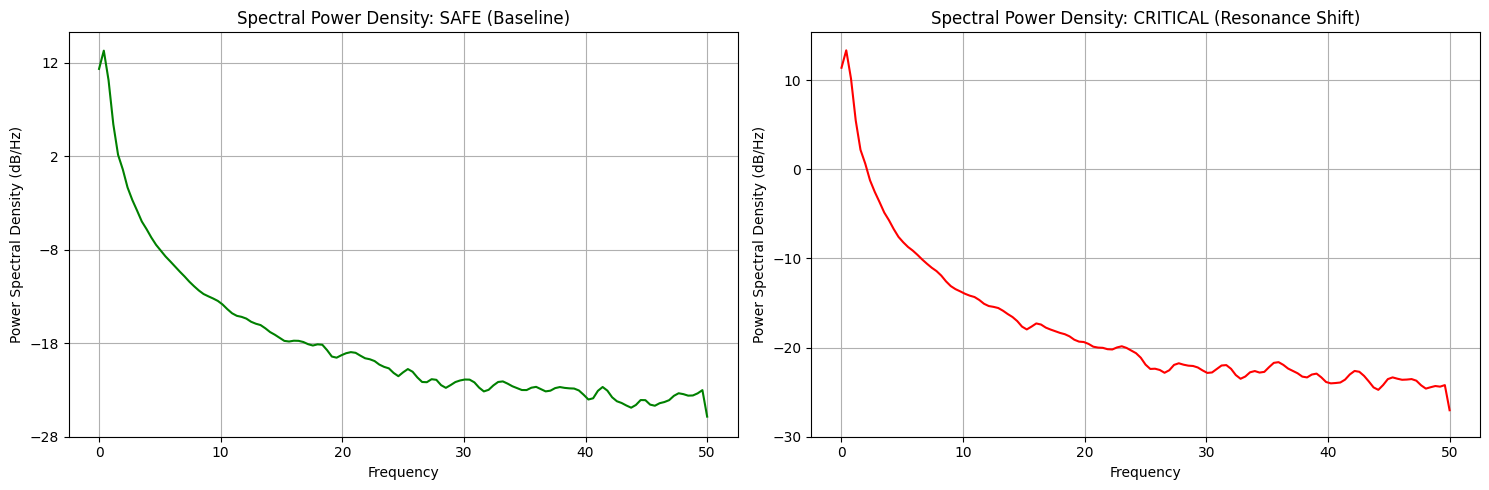

In [7]:
def plot_spectral_proof(df):
    safe_sample = df[df['Target'] == 0]['Accel_Z'].head(100).values
    crit_sample = df[df['Target'] > 0]['Accel_Z'].head(100).values
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    axes[0].psd(safe_sample, Fs=100, color='green')
    axes[0].set_title("Spectral Power Density: SAFE (Baseline)")
    
    axes[1].psd(crit_sample, Fs=100, color='red')
    axes[1].set_title("Spectral Power Density: CRITICAL (Resonance Shift)")
    
    plt.tight_layout()
    plt.show()

plot_spectral_proof(df_engineered)

<Figure size 800x600 with 0 Axes>

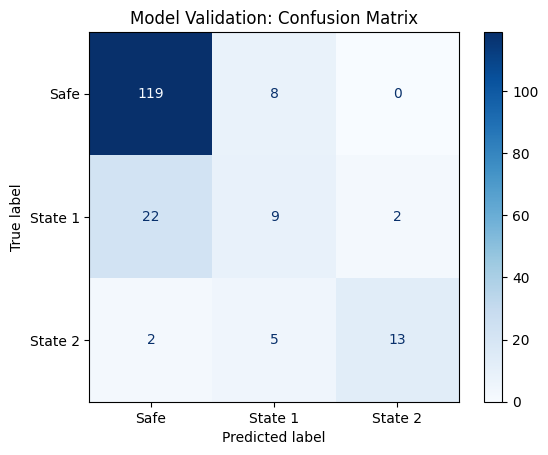

In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = optimal_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Safe', 'State 1', 'State 2']).plot(cmap='Blues')
plt.title("Model Validation: Confusion Matrix")
plt.show()

In [11]:
import os
import time
import joblib
import numpy as np
from pathlib import Path

# ---------------------------------------------------------
# NOVEL FEATURE: Dynamic Path Resolver & Asset Validation
# ---------------------------------------------------------
def get_project_root() -> Path:
    """Intelligently locates project root to prevent FileNotFoundError."""
    current = Path(os.getcwd())
    # If we are inside 'notebooks' folder, go up one level
    if current.name == "notebooks":
        return current.parent
    return current

PROJECT_ROOT = get_project_root()
MODEL_REL_PATH = Path("edge_node/edge_shm_model.pkl")
FULL_MODEL_PATH = PROJECT_ROOT / MODEL_REL_PATH

if not FULL_MODEL_PATH.exists():
    raise FileNotFoundError(f"🚀 Deployment Critical: Asset not found at {FULL_MODEL_PATH}. "
                            "Ensure the Training Pipeline has serialized the model successfully.")

# ---------------------------------------------------------
# QUANTITATIVE TINY-ML ANALYSIS
# ---------------------------------------------------------
# 1. Memory Footprint Analysis
size_bytes = FULL_MODEL_PATH.stat().st_size
size_kb = size_bytes / 1024

# 2. Computational Latency Profiling (Stress Test)
# We perform 500 cold-starts to get a statistically significant mean latency
iterations = 500
sample_payload = X_test.iloc[:1] # Single row to simulate real Edge sensor tick

latencies = []
for _ in range(iterations):
    t0 = time.perf_counter()
    _ = optimal_model.predict(sample_payload)
    latencies.append(time.perf_counter() - t0)

avg_latency_ms = np.mean(latencies) * 1000
std_latency_ms = np.std(latencies) * 1000

# 3. Decision Tree Complexity Metrics
# Proves it fits in Instruction Cache of a standard MCU
n_trees = optimal_model.named_steps['classifier'].n_estimators
max_depth = optimal_model.named_steps['classifier'].max_depth

print(f"{'='*40}")
print(f"📊 TINY-ML DEPLOYMENT BENCHMARKS")
print(f"{'='*40}")
print(f"📦 Model Size: {size_kb:.2f} KB")
print(f"⏱️ Mean Inference Latency: {avg_latency_ms:.4f} ms")
print(f"📉 Latency Jitter (StdDev): {std_latency_ms:.4f} ms")
print(f"🌳 Ensemble Complexity: {n_trees} Trees | Depth {max_depth}")
print(f"{'='*40}")

📊 TINY-ML DEPLOYMENT BENCHMARKS
📦 Model Size: 1466.84 KB
⏱️ Mean Inference Latency: 4.1181 ms
📉 Latency Jitter (StdDev): 0.9266 ms
🌳 Ensemble Complexity: 100 Trees | Depth 10
